 Modèle Baseline 2 — TF-IDF + SVM Linéaire
**Pipeline** : TfidfVectorizer (bigrams) → LinearSVC (balanced) → CalibratedClassifierCV


In [1]:
# ═══════════════════════════════════════════════════════
# SETUP
# ═══════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/Projet_Sentiment_Analysis'
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
FIG_DIR     = os.path.join(PROJECT_DIR, 'figures')

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

LABEL_NAMES = {0: 'négatif', 1: 'neutre', 2: 'positif'}
print("✅ Setup terminé")

Mounted at /content/drive
✅ Setup terminé


In [2]:
# ═══════════════════════════════════════════════════════
# CHARGEMENT
# ═══════════════════════════════════════════════════════
df_train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val.csv'))
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

X_train_text = df_train['texte_clean'].fillna('').values
X_val_text   = df_val['texte_clean'].fillna('').values
X_test_text  = df_test['texte_clean'].fillna('').values

y_train = df_train['label'].values
y_val   = df_val['label'].values
y_test  = df_test['label'].values

print(f" Train: {len(X_train_text)} | Val: {len(X_val_text)} | Test: {len(X_test_text)}")

📊 Train: 9285 | Val: 1161 | Test: 1161


In [3]:
# ═══════════════════════════════════════════════════════
# TF-IDF + SVM
# ═══════════════════════════════════════════════════════

# 1. Vectorisation TF-IDF avec bigrams
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),     # unigrams + bigrams
    min_df=2,
    max_df=0.95,
    sublinear_tf=True       # applique 1 + log(tf) → meilleure performance
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf   = tfidf.transform(X_val_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print(f" Matrice TF-IDF : {X_train_tfidf.shape}")

# 2. Entraînement SVM linéaire
print("\n Entraînement du SVM...")
start = time.time()

svm = LinearSVC(
    class_weight='balanced',    # gère le déséquilibre automatiquement
    C=1.0,
    max_iter=10000,
    random_state=42
)

# Calibration pour obtenir des probabilités (utile pour l'analyse)
svm_calibrated = CalibratedClassifierCV(svm, cv=3)
svm_calibrated.fit(X_train_tfidf, y_train)

train_time = time.time() - start
print(f" Entraînement terminé en {train_time:.1f}s")

📊 Matrice TF-IDF : (9285, 15000)

🚀 Entraînement du SVM...
✅ Entraînement terminé en 2.6s


📊 Val F1-macro : 0.5647

📊 RÉSULTATS — TF-IDF + SVM
   Accuracy  : 0.8295
   F1-macro  : 0.5663

📋 Classification Report :
              precision    recall  f1-score   support

     négatif       0.78      0.84      0.81       395
      neutre       0.00      0.00      0.00        84
     positif       0.86      0.93      0.89       682

    accuracy                           0.83      1161
   macro avg       0.55      0.59      0.57      1161
weighted avg       0.77      0.83      0.80      1161



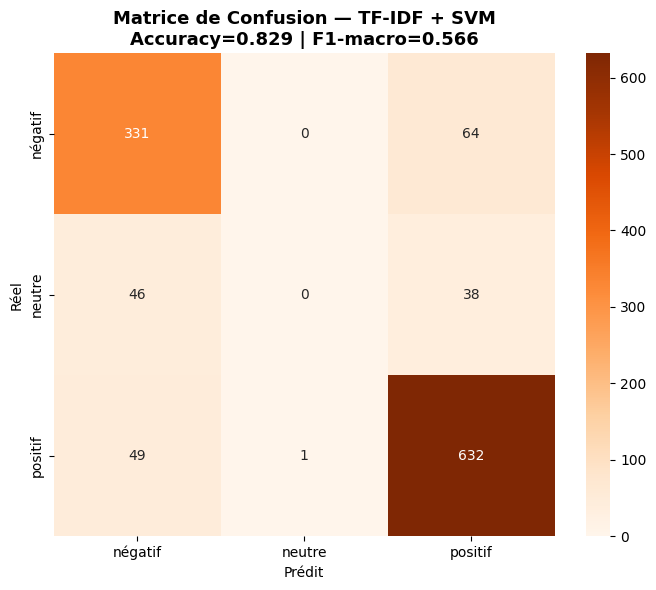

In [4]:
# ═══════════════════════════════════════════════════════
# ÉVALUATION SUR LE TEST SET
# ═══════════════════════════════════════════════════════
# Évaluation sur val (pour info)
val_preds = svm_calibrated.predict(X_val_tfidf)
val_f1    = f1_score(y_val, val_preds, average='macro')
print(f" Val F1-macro : {val_f1:.4f}")

# Évaluation sur test
test_preds = svm_calibrated.predict(X_test_tfidf)
test_acc   = accuracy_score(y_test, test_preds)
test_f1    = f1_score(y_test, test_preds, average='macro')

print("\n" + "="*60)
print("📊 RÉSULTATS — TF-IDF + SVM")
print("="*60)
print(f"   Accuracy  : {test_acc:.4f}")
print(f"   F1-macro  : {test_f1:.4f}")
print(f"\n Classification Report :")
print(classification_report(y_test, test_preds, target_names=['négatif','neutre','positif']))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['négatif','neutre','positif'],
            yticklabels=['négatif','neutre','positif'])
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title(f'Matrice de Confusion — TF-IDF + SVM\nAccuracy={test_acc:.3f} | F1-macro={test_f1:.3f}',
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'confusion_tfidf_svm.png'), dpi=150, bbox_inches='tight')
plt.show()